# Pipeline di Classificazione Curriculum Vitae (Resume)

Questo notebook implementa una pipeline di Machine Learning per classificare i CV in categorie.

**Step:**
1. Caricamento e Pulizia Dati
2. Split del Dataset (Train / Validation / Test)
3. Feature Extraction (TF-IDF)
4. Addestramento Modello (Linear SVM)
5. Valutazione
6. Inferenza

In [3]:
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from wordcloud import WordCloud
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
%load_ext autoreload
%autoreload 2
from tools import utils as u, plotting as up

RANDOM_STATE = 42

# 1. Caricamento e Preprocessing dei Dati

In [ ]:
# preprocessamento -> basta eseguirlo una volta nella vita e poi lo salviamo (tempo di esecuzione ~1m 16s)
df = pd.read_csv('data/Resume.csv')
df['text'] = df['Resume_str'].apply(u.preprocess_text)
df.to_csv('data/ppresume.csv')

Dataset caricato con successo: 2484 righe, 6 colonne

Distribuzione delle Categorie:
Media: 103.5
Valori sotto la media: ['ARTS', 'TEACHER', 'APPAREL', 'DIGITAL-MEDIA', 'AGRICULTURE', 'AUTOMOBILE', 'BPO']
Valori nulli: 2484
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


C:\Users\matti\AppData\Local\Temp\ipykernel_21320\62619977.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(categories.index, rotation=45, ha="right")


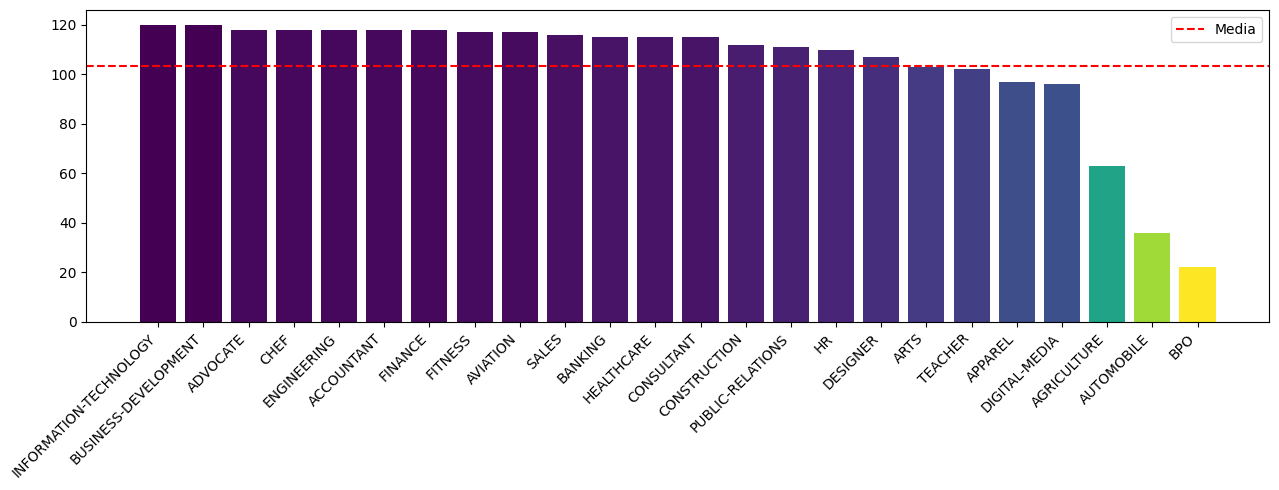

In [4]:


df = pd.read_csv('data/ppresume.csv')

## ------- Visualizzazione delle classi e altri dati
print(f"Dataset caricato con successo: {df.shape[0]} righe, {df.shape[1]} colonne")
print("\nDistribuzione delle Categorie:")

categories = df['Category'].value_counts()
meanv = categories.values.mean()

print(f"Media: {meanv}")
print(f"Valori sotto la media: {list(categories[categories < meanv].index)}")
print(f"Valori nulli: {df['text'].isna().count()}")
print(categories)
df = df.dropna()


## ------ PLOT
fig, ax = plt.subplots(figsize=(13, 5))
norm = plt.Normalize(categories.min(), categories.max())
colors = plt.cm.viridis_r(norm(categories.values))
ax.bar(categories.index, categories.values, color=colors)
ax.axhline(y=meanv, color='r', linestyle='--', label='Media')
ax.set_xticklabels(categories.index, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## 1.1 Wordcloud

In [ ]:
MAX_WORDS = 500

wc = WordCloud(
    width=800, 
    height=700, 
    background_color='white',
    max_words=MAX_WORDS,
    contour_width=0,
    colormap='viridis'  # 'viridis', 'plasma', or 'inferno' work well for data
)

fig = up.wordcloud(wc, df["text"], MAX_WORDS, ENGLISH_STOP_WORDS)
fig.savefig("data/wordcloud/wordcloud_overall.png", dpi=300)

for category in df['Category'].unique():
    category_df = df[df['Category'] == category]
    fig = up.wordcloud(wc, category_df["text"], MAX_WORDS, ENGLISH_STOP_WORDS)
    fig.savefig(f"data/wordcloud/wordcloud_{category}.png", dpi=300)


# 2 Feature Extraction
Esistono due principali metodologie di Feature Extraction:
- Bag of words
- TF-IDF

In [ ]:
# Step 1: preprocessing (è già stato fatto nella wordcloud)
# df["text"] = df["Resume_str"].apply(u.preprocess_text)
# df["text"].sample(10)

# Step 2: parole univoche (solo per dimostrazione)
unique_words = u.unique_text(df["text"])
print(len(unique_words))
wordsdf = pd.DataFrame(unique_words)

word2count = {} 
for data in df["text"]: 
    words = nltk.word_tokenize(data) 
    for word in words: 
        if word not in word2count.keys(): 
            word2count[word] = 1
        else: 
            word2count[word] += 1


## TF-IDF
Utilizziamo **TF-IDF (Term Frequency - Inverse Document Frequency)**. 
È molto efficace per il testo perché penalizza le parole troppo comuni (stop words) e valorizza quelle distintive per ogni categoria.
TF-IDF è il prodotto di TF e IDF, dove la prima è alta per un termine che si ripete tante volte all'interno di un documento e la seconda, invece, è alta se lo stesso termine si ripete raramente tra tutti i documenti. In questo caso signfica che il termine ha molta rilevanza per categorizzare un documento e distinguerlo da altri.

In [4]:
# Inizializzazione del vettorizzatore
# max_features=5000 limita il vocabolario alle 5000 parole più importanti per ridurre la dimensionalità
vectorizer = TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 3))
X = vectorizer.fit_transform(df["text"])
y = df["Category"]

print(f"Shape della matrice di feature (Train): {X.shape}")

Shape della matrice di feature (Train): (2483, 3000)


# 3. Suddivisione del Dataset (Train + Validation + Test)

Suddividiamo i dati in:
- **Train Set (70%)**: Per addestrare il modello.
- **Validation Set (15%)**: Per il tuning degli iperparametri (implicito in questa pipeline semplificata).
- **Test Set (15%)**: Per la valutazione finale imparziale.

In [ ]:
# con stratify per impedire assenza di rappresentatività
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

print(f"Dimensioni Train: {X_train.shape[0]}")
print(f"Dimensioni Validation: {X_val.shape[0]}")
print(f"Dimensioni Test: {X_test.shape[0]}")

# 4. Addestramento del Classificatore

## Confronto Modelli
Implementiamo un confronto tra diversi modelli:
- **Naive Bayes**: sebbene più veloce, tende a essere superato dalle SVM nella gestione delle dipendenze tra termini.
- **Random Forest**: risulta spesso inefficiente su vettori sparsi di grandi dimensioni senza una preventiva riduzione della dimensionalità.
- **Deep Learning**: una rete neurale feed-forward su dati TF-IDF raramente offre vantaggi significativi rispetto a una SVM lineare, a fronte di una maggiore complessità gestionale.

In [ ]:
X = df['text']
y = df['Category']

# 1. Encoding delle etichette
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Split iniziale
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_encoded, test_size=0.05, stratify=y_encoded, random_state=RANDOM_STATE
)

# 3. Setup Cross-Validation (ridotto a 5 split - sufficiente per confronto robusto)
skf = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)

# 4. Parametri TF-IDF (definiti una sola volta)
tfidf_params = {'stop_words': "english", 'max_features': 3000, 'ngram_range': (1, 3)}

# 5. Definizione modelli (solo classificatori, TF-IDF separato)
model_definitions = {
    'Linear SVC': LinearSVC(random_state=RANDOM_STATE, dual='auto'),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
    'Deep Learning (MLP)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=RANDOM_STATE)
}

# 6. Tracciamento risultati (usando liste per calcolare media/std)
results = {name: [] for name in model_definitions}
best_acc = 0.0
winning_model = None
best_model_details = {}

print("--- Confronto Performance (Accuracy su Validation Set) ---")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    # Estrazione dati del fold
    X_fold_train = X_train_full.iloc[train_idx]
    X_fold_val = X_train_full.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_full[train_idx], y_train_full[val_idx]
    
    # ⚡ OTTIMIZZAZIONE CHIAVE: TF-IDF calcolato UNA SOLA VOLTA per fold
    tfidf = TfidfVectorizer(**tfidf_params)
    X_train_tfidf = tfidf.fit_transform(X_fold_train)
    X_val_tfidf = tfidf.transform(X_fold_val)
    
    print(f"\n📊 FOLD {fold_idx + 1}/5 --------")
    
    for name, clf_template in model_definitions.items():
        # Clone del modello per evitare interferenze tra fold
        from sklearn.base import clone
        clf = clone(clf_template)
        
        # Training diretto sulla matrice TF-IDF (niente pipeline ridondante)
        clf.fit(X_train_tfidf, y_fold_train)
        
        # Predizione e valutazione
        preds = clf.predict(X_val_tfidf)
        acc = accuracy_score(y_fold_val, preds)
        results[name].append(acc)
        
        print(f"  {name}: {acc:.4f}")
        
        # Tracking del migliore (salviamo pipeline completa per inferenza)
        if acc > best_acc:
            best_acc = acc
            # Ricostruiamo la pipeline per il modello vincitore
            winning_model = Pipeline([
                ('tfidf', TfidfVectorizer(**tfidf_params)),
                ('clf', clone(clf_template))
            ]).fit(X_fold_train, y_fold_train)
            best_model_details = {'name': name, 'fold': fold_idx, 'accuracy': acc}

# 7. Riepilogo con statistiche aggregate
print("\n" + "=" * 50)
print("📈 RISULTATI AGGREGATI (Media ± Std su 5 fold):")
print("=" * 50)

for name, accs in results.items():
    mean_acc = np.mean(accs)
    std_acc = np.std(accs)
    print(f"{name:20s}: {mean_acc:.4f} ± {std_acc:.4f}")

print("\n" + "=" * 50)
print(f"🏆 MIGLIORE SINGOLA ACCURACY: {best_acc:.4f}")
print(f"🏆 MODELLO VINCITORE: {best_model_details['name']} (Fold: {best_model_details['fold'] + 1})")

--- Confronto Performance (Accuracy su Validation Set) ---

📊 FOLD 1/5 --------
  Linear SVC: 0.6462
  Naive Bayes: 0.5572
  Random Forest: 0.6653
  XGBoost: 0.6949


# 5. Valutazione del Modello
Valutiamo le performance sul **Test Set**.

In [8]:
# 1. Usa il test set che abbiamo separato all'inizio (X_test, y_test)
# Ricorda: y_test contiene già i numeri (0, 1, 2...) grazie al LabelEncoder
y_pred_numeric = winning_model.predict(X_test)

# 2. Per il report, vogliamo i nomi delle categorie, non i numeri
# Usiamo le.inverse_transform per tornare ai nomi originali
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_numeric)

print("--- Classification Report (Test Set) ---")
# Passiamo i nomi reali al report per renderlo leggibile
print(classification_report(y_test_labels, y_pred_labels))

final_acc = accuracy_score(y_test, y_pred_numeric)
print(f"Accuracy finale sul Test Set: {final_acc:.4f}")

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

            ACCOUNTANT       0.44      0.67      0.53         6
              ADVOCATE       0.83      0.83      0.83         6
           AGRICULTURE       1.00      0.33      0.50         3
               APPAREL       1.00      0.60      0.75         5
                  ARTS       0.25      0.20      0.22         5
            AUTOMOBILE       0.00      0.00      0.00         2
              AVIATION       1.00      0.83      0.91         6
               BANKING       0.75      0.50      0.60         6
                   BPO       0.00      0.00      0.00         1
  BUSINESS-DEVELOPMENT       0.67      1.00      0.80         6
                  CHEF       0.71      0.83      0.77         6
          CONSTRUCTION       0.80      0.67      0.73         6
            CONSULTANT       0.00      0.00      0.00         6
              DESIGNER       0.83      1.00      0.91         

/home/began/srcs/data_science/DataScience/Progetto_NLP/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/began/srcs/data_science/DataScience/Progetto_NLP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/began/srcs/data_science/DataScience/Progetto_NLP/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/began/srcs/d

In [ ]:
import plotly.express as px
from sklearn.metrics import confusion_matrix

# 1. Recuperiamo i nomi reali delle categorie dall'encoder
# le.classes_ contiene i nomi in ordine alfabetico corrispondente ai numeri 0-23
labels_text = le.classes_

# 2. Assicuriamoci che y_val e y_pred siano nello stesso formato (testuale)
# Se sono numeri, li trasformiamo in nomi per il grafico
y_val_text = le.inverse_transform(y_val)
y_pred_text = le.inverse_transform(y_pred)

# 3. Calcoliamo la matrice usando i nomi testuali come riferimento per l'ordine
cm = confusion_matrix(y_val_text, y_pred_text, labels=labels_text)

# 4. Creazione del grafico Plotly
fig = px.imshow(
    cm, 
    x=labels_text, 
    y=labels_text, 
    color_continuous_scale='Blues',
    labels=dict(x='Predetto', y='Reale', color='Conteggio'),
    text_auto=True, 
    title='Matrice di Confusione - Analisi Errori per Categoria',
    height=900,  # Leggermente più alto per far spazio ai nomi
    width=900
)

# Miglioriamo la leggibilità degli assi
fig.update_layout(
    xaxis_tickangle=-45, # Ruota i nomi delle categorie per non sovrapporli
    xaxis_title='Categoria Predetta',
    yaxis_title='Categoria Reale'
)

fig.show()

# 6. Inferenza
Utilizziamo il modello addestrato su un nuovo testo mai visto.

In [10]:
counter = 0
errori = []
stack = df.copy()
while True:
    # 1. Prendi un indice casuale
    idx = None
    try:
        idx = stack.sample(1).index[0]
    except:
        break
    # 2. Estrai i dati (il "pop" vero e proprio)
    sr = stack.loc[idx]
    
    # 3. Rimuovi la riga dallo stack usando l'indice e inplace=True
    stack.drop(idx, inplace=True)

    text = sr['text']
    truth_label = sr['Category']

    # Il resto del tuo codice rimane uguale
    svec = vectorizer.transform([text])
    prediction = model.predict(svec)[0]
    counter += 1
    
    if prediction != truth_label:
        #print(f"Dopo {counter} tentativi")
        # print(f"Testo Input:\n{text.strip()}")
        # print(f"\nCategoria Predetta: {prediction}")
        # print(f"Categoria Reale: {truth_label}")
        errori.append(counter)
        counter = 0

print(f"Errori {len(errori)}")
print(f"In media uno ogni {np.mean(errori)}")

Errori 105
In media uno ogni 23.295238095238094
